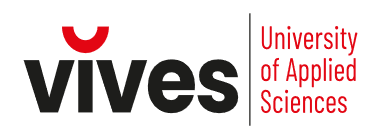<br>


**DATA ENGINEERING**<br>
APPLIED COMPUTER SCIENCE<br>
VIVES BUSINESS ACADEMY<br>
Andy Louwyck

---



---



# **EXPLORATORY DATA ANALYSIS: EXERCISE**

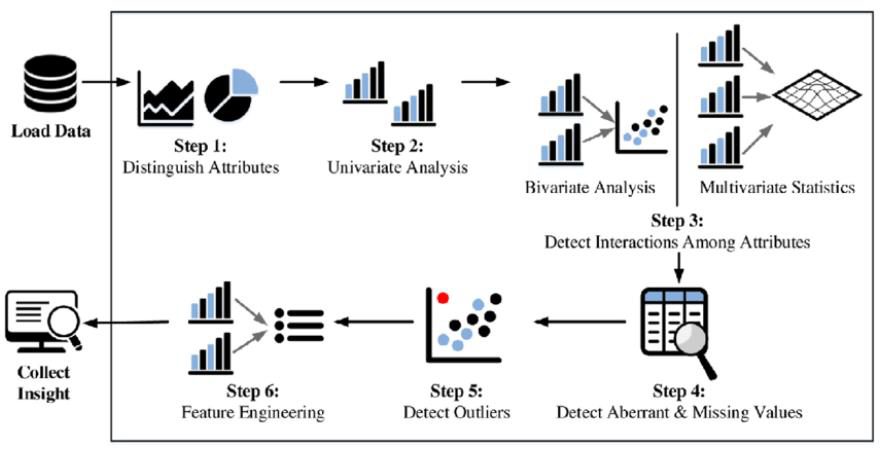

In this notebook, we are again using a dataset with police data and linked to weather data. The original datasets are available on [Kaggle](https://www.kaggle.com/). In the previous notebook, we prepared the data to apply machine learning to it.

In this phase, we will further explore the data and extract features. This phase is called **exploratory data analysis**, or EDA for short. In fact, we have already performed several steps of the EDA in the previous notebook as we have explored the attributes, performed univariate analyses, and ensured that there are no missing values or outliers in the dataset.

However, we have not yet performed bivariate or multivariate analyses. We want to answer the question of whether the variables or features in the dataset contain sufficient information to contribute effectively to accurate predictions. Ideally, the features should be independent of each other, which we can test by examining the extent to which they correlate. In this notebook, we will therefore have to apply some statistics!

## **Univariate analysis**

First and foremost, we start by reading in the curated dataset that we saved in the previous notebook as `'police_controls.csv'`. Show the first 5 records.

In [ ]:
import pandas as pd

df = pd.read_csv('police_controls.csv')
df.head()

,year,month,day,hour,driver_gender,driver_age,driver_race,violation,search_conducted,stop_outcome,is_arrested,stop_duration,drugs_related_stop,weather,TMIN,TMAX,AWND,WSF2
0,2005,January,Sunday,1,M,20.0,White,Speeding,False,Citation,False,0-15 Min,False,bad,-2.222222,6.666667,9.40,14.1
1,2005,January,Tuesday,8,M,40.0,White,Speeding,False,Citation,False,0-15 Min,False,good,-14.444444,-9.444444,14.09,23.0
2,2005,January,Sunday,23,M,33.0,White,Speeding,False,Citation,False,0-15 Min,False,worse,-15.000000,-2.222222,26.84,45.0
3,2005,February,Sunday,17,M,19.0,White,Other,False,Arrest Driver,True,16-30 Min,False,bad,-7.777778,1.111111,6.93,17.0
4,2005,March,Monday,10,F,21.0,White,Speeding,False,Citation,False,0-15 Min,False,good,-3.888889,5.555556,10.96,19.9


With the `info()` method, we get an overview of the columns, how many non-null values each column has, and what the data type is of those values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86137 entries, 0 to 86136
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                86137 non-null  int64  
 1   month               86137 non-null  object 
 2   day                 86137 non-null  object 
 3   hour                86137 non-null  int64  
 4   driver_gender       86137 non-null  object 
 5   driver_age          86137 non-null  float64
 6   driver_race         86137 non-null  object 
 7   violation           86137 non-null  object 
 8   search_conducted    86137 non-null  bool   
 9   stop_outcome        86137 non-null  object 
 10  is_arrested         86137 non-null  bool   
 11  stop_duration       86137 non-null  object 
 12  drugs_related_stop  86137 non-null  bool   
 13  weather             86137 non-null  object 
 14  TMIN                86137 non-null  float64
 15  TMAX                86137 non-null  float64
 16  AWND

Of course, there are no missing values in the dataframe and all columns have the correct data type because we cleaned the dataset in a previous notebook.

With the `describe()` method, we can already request a few summarizing statistics of the numerical variables.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,86137.0,2010.278521,3.043562,2005.000000,2008.000000,2010.000000,2013.000000,2015.000000
hour,86137.0,11.674960,6.464073,0.000000,8.000000,11.000000,16.000000,23.000000
driver_age,86137.0,34.013072,12.716164,15.000000,24.000000,31.000000,43.000000,99.000000
TMIN,86137.0,6.354541,9.322087,-20.555556,-1.111111,6.666667,14.444444,25.000000
TMAX,86137.0,16.439451,9.945874,-9.444444,8.333333,17.222222,25.000000,38.888889
AWND,86137.0,8.440384,3.218162,0.220000,6.260000,8.050000,10.070000,26.840000
WSF2,86137.0,19.051942,5.423542,4.900000,15.000000,17.900000,21.900000,48.100000


The question is now whether we will consider all those variables as numerical. Variables `'month'` and `'day'` are categorical in this case, so we will also consider `'year'` and `'hour'` as categorical, even though they are represented by a numerical value. The age of the driver `'driver_age'` could also be interpreted as categorical.

The remaining 4 numerical variables related to temperature, wind, and weather are effectively quantitative. Make a histogram for each of these variables (`'TMIN'`, `'TMAX'`, `'AWND'`, and `'WSF2'`) using 2x2 subplots.

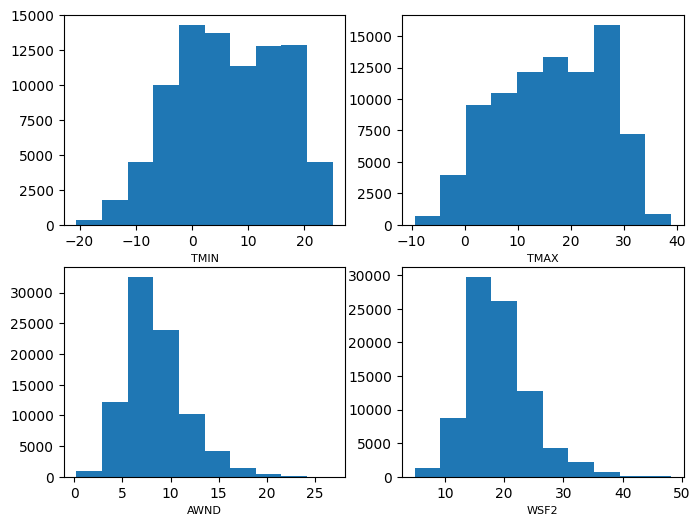

In [ ]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(2, 2, figsize=(8, 6))
for ax, attr in zip(axes.flatten(), ['TMIN', 'TMAX', 'AWND', 'WSF2']):
    ax.hist(df[attr])
    ax.set_xlabel(attr, fontdict=dict(fontsize=8))

At first glance, these variables do not appear to be normally distributed. Let's test that with the [Shapiro-Wilk test](https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test). The code for this test is as follows:

In [ ]:
from scipy.stats import shapiro

# Shapiro-Wilk test
def shapiro_wilk(test_variable, significance_level=0.05):
    '''
    Perform Shapiro-Wilk test for normality
    - test_variable: the variable to test (array_like)
    - significance_level: significance level (default 0.05)
    '''
    statistic, p_value = shapiro(test_variable)
    # Check the p-value
    if p_value > significance_level:
        print("Data looks normally distributed (fail to reject H0)")
    else:
        print("Data does not look normally distributed (reject H0)")

Test now if the meteorological variables are normally distributed or not:

In [ ]:
for variable in ['TMIN', 'TMAX', 'AWND', 'WSF2']:
    print(variable)
    shapiro_wilk(df[variable])
    print()

TMIN
Data does not look normally distributed (reject H0)

TMAX
Data does not look normally distributed (reject H0)

AWND
Data does not look normally distributed (reject H0)

WSF2
Data does not look normally distributed (reject H0)



/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 86137.
  res = hypotest_fun_out(*samples, **kwds)


Let's consider the age of the drivers as a quantitative variable. Is this variable normally distributed? Make a new histogram and perform the test, and you will see that it is clearly not normally distributed!

Data does not look normally distributed (reject H0)


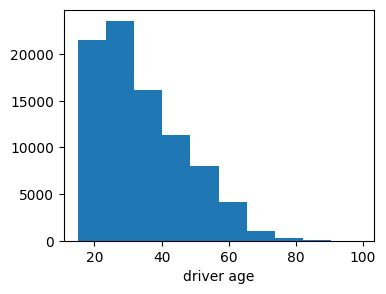

In [ ]:
_, ax = plt.subplots(figsize=(4, 3))
ax.hist(df['driver_age'])
ax.set_xlabel('driver age')
shapiro_wilk(df['driver_age'])

These are examples of univariate analyses because we are only studying one variable; hence, the adjective UNI-variate...

For the categorical variables, we have already done that in the previous notebook by looking at the frequencies. We can also visualize that using a bar plot or histogram. Do this for variables `'year'`, `'month'`, `'day'`, and `'hour'`. Create again 2x2 subplots.

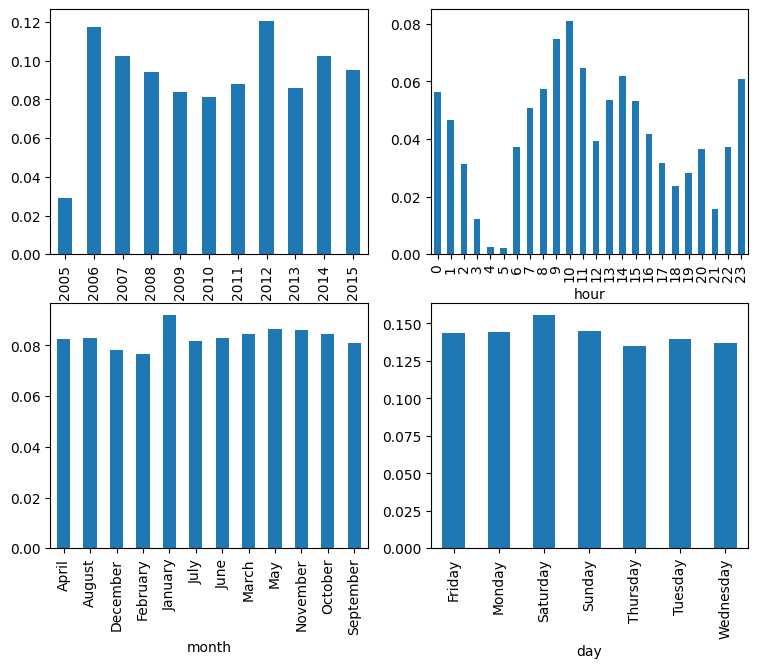

In [ ]:
_, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, attribute in zip(axes.flatten(), ['year', 'hour', 'month', 'day']):
    relative_frequency = df[attribute].value_counts(normalize=True).sort_index()
    relative_frequency.plot(kind='bar', ax=ax)

Of course, we can also use a pie chart or a pie diagram. Do this for `'driver_gender'` and `'driver_race'`, showing the relative frequencies on the chart. Place the two diagrams side by side.

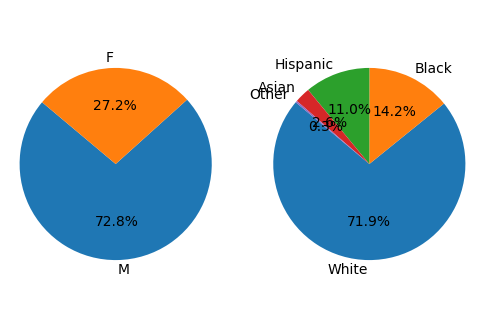

In [ ]:
_, axes = plt.subplots(1, 2, figsize=(6, 4))
for ax, attribute in zip(axes.flatten(), ['driver_gender', 'driver_race']):
    relative_frequency = df[attribute].value_counts(normalize=True)
    ax.pie(relative_frequency, labels=relative_frequency.index, autopct='%1.1f%%', startangle=140)
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

Now do the same for all variables related to the police controls:

`['search_conducted', 'is_arrested', 'stop_duration', 'drugs_related_stop']`

Create 2x2 subplots.

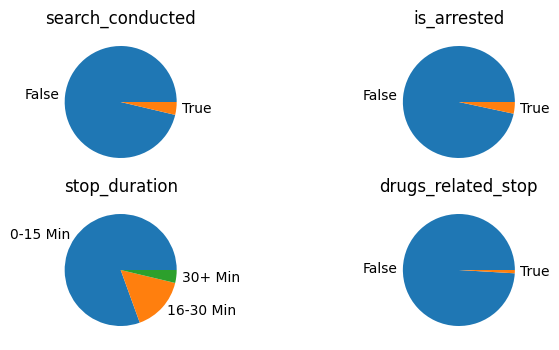

In [ ]:
_, axes = plt.subplots(2, 2, figsize=(8, 4))
for ax, attr in zip(axes.flatten(), ['search_conducted', 'is_arrested', 'stop_duration', 'drugs_related_stop']):
    relative_frequency = df[attr].value_counts(normalize=True)
    relative_frequency.plot(kind='pie', ax=ax)
    ax.set_ylabel("");
    ax.set_title(attr);

Finally, we have the following categorical variables for which we create bar plots that are placed side by side:

`['violation', 'stop_outcome', 'weather']`

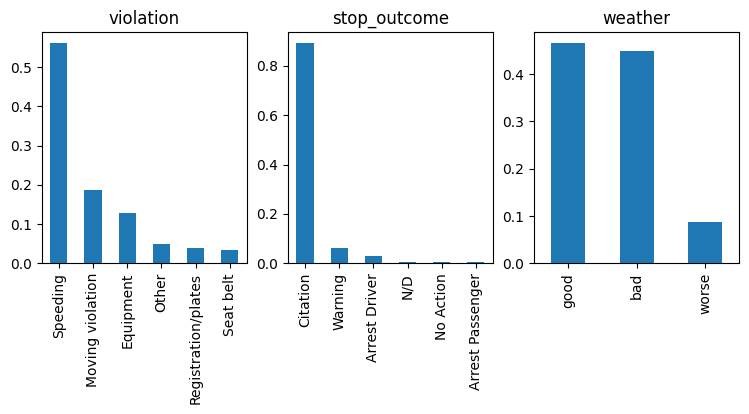

In [ ]:
_, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, attr in zip(axes.flatten(), ['violation', 'stop_outcome', 'weather']):
    relative_frequency = df[attr].value_counts(normalize=True)
    relative_frequency.plot(kind='bar', ax=ax)
    ax.set_xlabel("");
    ax.set_title(attr);

We see that more than 50% of the violations are related to excessive speed (`'Speeding'`). That's what we're going to try to predict: will the driver receive a speeding ticket or not? Therefore, add an extra boolean column `'Speeding'` with the **target**: label `True` if it's a speeding offense and label `False` if it's not. Show as an example the first 5 rows of the column `'violation'` together with the new column `'Speeding'`:

In [ ]:
df['Speeding'] = df['violation'] == 'Speeding'
df[['violation', 'Speeding']].head()

,violation,Speeding
0,Speeding,True
1,Speeding,True
2,Speeding,True
3,Other,False
4,Speeding,True


As we use `'Speeding'` as a label, is the dataset balanced?

In [ ]:
# the dataset is not perfectly balanced because there are 56% True labels
df.Speeding.mean()

np.float64(0.5609436130814864)

In principle, we should now drop column `'violation'`, but we will not do that for the time being, as we are going to use that variable in the bivariate analysis.

## **Bivariate analysis**

Typical for the bivariate analysis is determining the correlation between the variables. Calculating the [Pearson correlation coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) only makes sense for quantitative variables. Therefore, create a correlation matrix for the 5 numerical variables:

`['driver_age', 'TMIN', 'TMAX', 'AWND', 'WSF2']`

Use the `DataFrame` method `corr()`.

In [ ]:
corr_matrix = df[['driver_age', 'TMIN', 'TMAX', 'AWND', 'WSF2']].corr()
corr_matrix

,driver_age,TMIN,TMAX,AWND,WSF2
driver_age,1.000000,-0.006233,-0.006344,-0.002600,0.002046
TMIN,-0.006233,1.000000,0.937523,-0.135605,-0.136412
TMAX,-0.006344,0.937523,1.000000,-0.181909,-0.113335
AWND,-0.002600,-0.135605,-0.181909,1.000000,0.811930
WSF2,0.002046,-0.136412,-0.113335,0.811930,1.000000


You can also nicely visualize that matrix using a `heatmap` from the seaborn library.

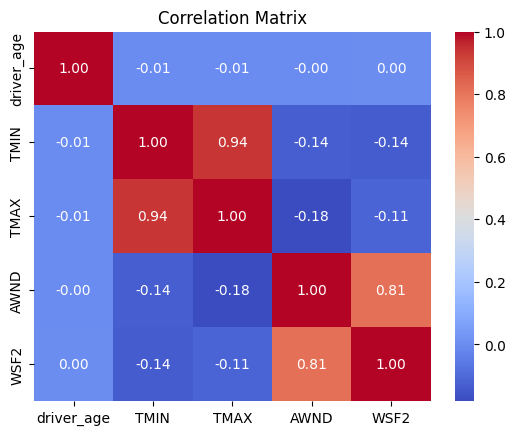

In [ ]:
import seaborn as sbn

sbn.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Correlation Matrix');

As expected, there is no correlation between the driver's age and the meteorological variables. However, there is a high correlation between the two 'temperature' variables `'TMIN'` and `'TMAX'`, and between the two 'wind' variables `'AWND'` and `'WSF2'`. However, when training a machine learning model, we want features that are as independent of each other as possible, or in other words, that correlate as little as possible!

It makes no sense to set up a Pearson correlation matrix for categorical variables. But is there an alternative? Well, for example, we can apply [Cramér's V](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V), which is a measure of association between two nominal variables. Just like the correlation coefficient, Cramér's V is also a number between 0 and 1, where 0 indicates no association, while 1 represents a perfect relationship. You can calculate Cramér's V using the [Chi-squared test](https://en.wikipedia.org/wiki/Chi-squared_test). This is the code:

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(variable1, variable2):
    '''
    Calculate Cramér's V between two categorical variables
    - variable1: first categorical variable (array_like)
    - variable2: second categorical variable (array_like)
    '''
    # Contingency table
    contingency_table = pd.crosstab(variable1, variable2)
    # Chi-square test
    chi2, _, _, _ = chi2_contingency(contingency_table)
    # Number of observations
    n = contingency_table.sum().sum()
    # Cramér's V calculation
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    # Output
    return cramers_v

Write the code to calculate an association matrix for a series of categorical variables. Use a function similar to the `DataFrame` method `corr` for creating the correlation matrix. Keep in mind that the association between a variable and itself is equal to 1, and that the order of the two variables for which the association is calculated does not matter.

In [ ]:
import numpy as np

def association_matrix(df):
    '''
    Calculate Cramér's V association matrix
    - df is a DataFrame with the categorical variables
    - returns a DataFrame with the association matrix
    '''
    n = len(df.columns)
    M = np.ones((n, n))  # initialzing the association matrix M
    for i, attribute1 in enumerate(df.columns):
        for j, attribute2 in enumerate(df.columns[i+1:]):  # M is symmetric with ones on the main diagonal
            M[i, j+i+1] = M[j+i+1, i] = cramers_v(df[attribute1], df[attribute2])
    return pd.DataFrame(data=M, columns=df.columns, index=df.columns)  # return DataFrame

Now apply your function to calculate the association matrix for the categorical variables of the dataset. These are all variables except for the meteorological variables. You don't need to include the target in the analysis, as it is derived from variable `'violation'`. Since the association matrix is extensive, visualize it using a heatmap.

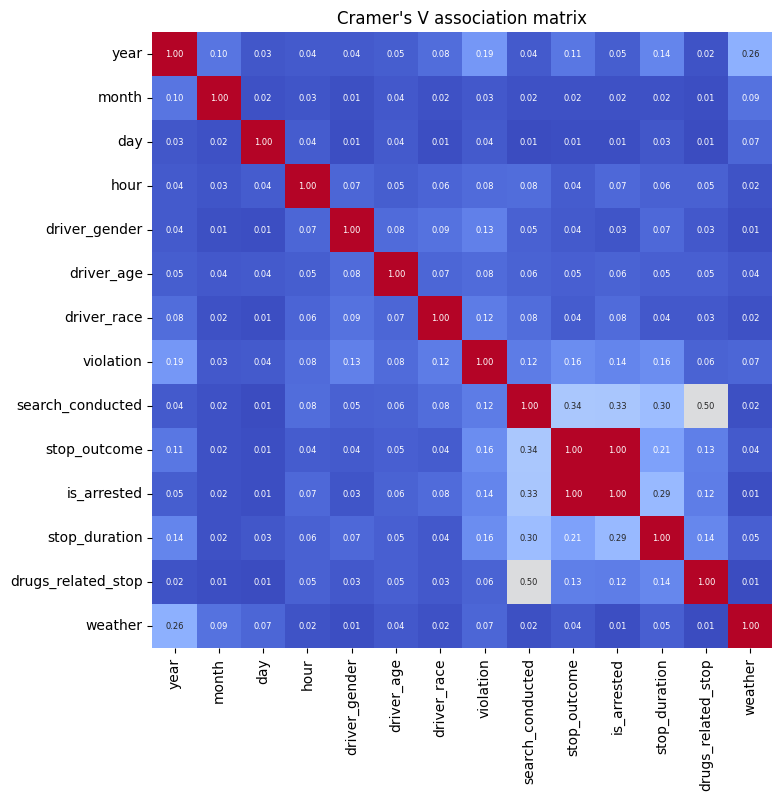

In [ ]:
M = association_matrix(df[df.columns[:-5]])  # the last 5 columns are not needed
plt.figure(figsize=(8, 8))
sbn.heatmap(M, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 6}, cbar=False)
plt.title("Cramer's V association matrix");

We see that there is a perfect association between variables `'stop_outcome'` and `'isarrested'`. It also makes sense that the latter column is derived from the former, and therefore we can remove `'isarrested'` from the dataset, as it does not provide extra information.

In [ ]:
df.drop('is_arrested', axis=1, inplace=True)
df.columns

Index(['year', 'month', 'day', 'hour', 'driver_gender', 'driver_age',
       'driver_race', 'violation', 'search_conducted', 'stop_outcome',
       'stop_duration', 'drugs_related_stop', 'weather', 'TMIN', 'TMAX',
       'AWND', 'WSF2', 'Speeding'],
      dtype='object')

For the rest, we see that the association between the other categorical features is very low, which is actually very good news! However, we derived the target `'Speeding'` from the column `'violation'`, which means that it may be difficult to predict this variable using the features in our dataset.

Since we derived the target from the feature `'violation'`, it is best to remove this column from our dataset:

In [ ]:
df.drop('violation', axis=1, inplace=True)
df.columns

Index(['year', 'month', 'day', 'hour', 'driver_gender', 'driver_age',
       'driver_race', 'search_conducted', 'stop_outcome', 'stop_duration',
       'drugs_related_stop', 'weather', 'TMIN', 'TMAX', 'AWND', 'WSF2',
       'Speeding'],
      dtype='object')

## **Principal Component Analysis**

The principal component analysis, or briefly **PCA**, is a form of *unsupervised learning* that allows us to perform *dimensionality reduction*. The dimensionality is a difficult word to refer to the number of variables or features. With PCA, we can thus reduce the number of features or columns in the dataset.

The problem is that PCA can only be applied to quantitative variables. In our dataset, we also have many categorical variables that do not strictly qualify for PCA. For such variables, we can apply the [multiple correspondence analysis](https://en.wikipedia.org/wiki/Multiple_correspondence_analysis), or briefly **MCA**. But in our dataset, we have both numerical and categorical variables. We can solve this by converting the categorical variables into binary variables using [one-hot encoding](https://en.wikipedia.org/wiki/One-hot), after which we can apply PCA to all variables.

In Scikit-Learn, we have the `OneHotEncoder` class in the `preprocessing` module. Try that class on variable `'weather'` and show the first 5 rows of the binary matrix that is returned:

In [ ]:
from sklearn.preprocessing import OneHotEncoder

one_hot = OneHotEncoder()
X = one_hot.fit_transform(df[['weather']]).toarray()
pd.DataFrame(data=X, columns=one_hot.categories_).head()  # converting to dataframe

,bad,good,worse
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,1.0,0.0


The same result can be achieved with the Pandas function `get_dummies()`. The advantage of this function is that we get a DataFrame as a result, making it immediately clear what the different columns stand for. Test this function out and reassign the returned DataFrame to variable `X`!

In [ ]:
X = pd.get_dummies(df['weather'])
X.head()

,bad,good,worse
0,True,False,False
1,False,True,False
2,False,False,True
3,True,False,False
4,False,True,False


Now apply one-hot encoding using `get_dummies` to all categorical variables with more than 2 classes:

`['year', 'month', 'day', 'hour', 'driver_race', 'stop_outcome', 'stop_duration']`

You need to convert the numerical values in columns `'year'` and `'hour'` to strings.

Save the resulting binary variables in a new Pandas DataFrame that you add to the DataFrame `X` that you created earlier. Use the Pandas function `concat` for this:

In [ ]:
T = pd.concat(
     [pd.get_dummies(df[attr].astype(str))
      for attr in ['year', 'month', 'day', 'hour', 'driver_race', 'stop_outcome', 'stop_duration']],
     axis=1)
X = pd.concat((X, T), axis=1)
X.head()

,bad,good,worse,2005,2006,2007,2008,2009,2010,2011,...,White,Arrest Driver,Arrest Passenger,Citation,N/D,No Action,Warning,0-15 Min,16-30 Min,30+ Min
0,True,False,False,True,False,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
1,False,True,False,True,False,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
2,False,False,True,True,False,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
3,True,False,False,True,False,False,False,False,False,False,...,True,True,False,False,False,False,False,False,True,False
4,False,True,False,True,False,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False


Convert boolean columns in `X` to integer columns:

In [ ]:
X = X.astype(int)
X.head()

,bad,good,worse,2005,2006,2007,2008,2009,2010,2011,...,White,Arrest Driver,Arrest Passenger,Citation,N/D,No Action,Warning,0-15 Min,16-30 Min,30+ Min
0,1,0,0,1,0,0,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0
1,0,1,0,1,0,0,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0
2,0,0,1,1,0,0,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0
3,1,0,0,1,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,1,0
4,0,1,0,1,0,0,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0


Add the categorical binary variables to DataFrame `X`:

`['driver_gender', 'search_conducted', 'drugs_related_stop']`

Convert those variables to `int` values.

In [ ]:
X = pd.concat([X,
               (df[['driver_gender']] == 'M').astype(int),
               df[['search_conducted', 'drugs_related_stop']].astype(int)],
              axis=1)
X.head()

,bad,good,worse,2005,2006,2007,2008,2009,2010,2011,...,Citation,N/D,No Action,Warning,0-15 Min,16-30 Min,30+ Min,driver_gender,search_conducted,drugs_related_stop
0,1,0,0,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,1,0,0
1,0,1,0,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,1,0,0
2,0,0,1,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,1,0,0
3,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
4,0,1,0,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0


Finally, we add the numerical variables to `X` after normalizing them. Since the univariate analysis has shown that none of these variables are normally distributed, we will not apply standardization based on mean and standard deviation, but we will simply rescale them based on minimum and maximum.

The 'driver_age' can be simply divided by 99, the maximum age.

In [ ]:
X = pd.concat([X, df[['driver_age']] / 99], axis=1)

When scaling meteorological variables, we must rescale using both maximum and minimum. We can use the `MinMaxScaler` class from Scikit-Learn for this. But we can also simply apply the following formula:

`(df[columns] - df[columns].min(axis=0)) / (df[columns].max(axis=0) - df[columns].min(axis=0))`

In [ ]:
columns = ['TMIN', 'TMAX', 'AWND', 'WSF2']
T = (df[columns] - df[columns].min(axis=0)) / (df[columns].max(axis=0) - df[columns].min(axis=0))
X = pd.concat((X, T), axis=1)
X.head()

,bad,good,worse,2005,2006,2007,2008,2009,2010,2011,...,16-30 Min,30+ Min,driver_gender,search_conducted,drugs_related_stop,driver_age,TMIN,TMAX,AWND,WSF2
0,1,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0.202020,0.402439,0.333333,0.344853,0.212963
1,0,1,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0.404040,0.134146,0.000000,0.521037,0.418981
2,0,0,1,1,0,0,0,0,0,0,...,0,0,1,0,0,0.333333,0.121951,0.149425,1.000000,0.928241
3,1,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0.191919,0.280488,0.218391,0.252066,0.280093
4,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0.212121,0.365854,0.310345,0.403456,0.347222


We have now transformed all features and stored them in DataFrame `X`. We could also have made use of the Scikit-Learn class `ColumnTransformer` which automatically performs all these transformations for us. Much more efficient!

Now, put the target `'Speeding'` into a Pandas Series `y` and convert it to data type `int`:

In [ ]:
y = df.Speeding.astype(int)
y.head()

,Speeding
0,1
1,1
2,1
3,0
4,1


We are now applying PCA, where we will reduce the dataset by retaining only the components that explain 90% of the variance.

In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA with n_components='mle' (maximum likelihood estimation)
pca = PCA(n_components='mle')

# Fit PCA on the data
pca.fit(X)

# Calculate the cumulative explained variance ratio
cumulative_explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# Determine the number of components that explain 90% of the variance
n_components = np.argmax(cumulative_explained_variance_ratio >= 0.90) + 1

# Re-fit PCA with the determined number of components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

# Print the number of components and the cumulative explained variance ratio
print("Number of components to explain 90% of variance:", n_components)
print("Cumulative explained variance ratio:", cumulative_explained_variance_ratio[n_components - 1])

Number of components to explain 90% of variance: 44
Cumulative explained variance ratio: 0.9001584024547858


That's nice! We have reduced the 79 columns in the dataset `X` to 44 columns in `X_pca`. Almost half of the columns thus fall away!

In [ ]:
print(X.shape)
print(X_pca.shape)

(86137, 79)
(86137, 44)


Does that make a big difference in the final performance of a machine learning model? To investigate the effect of PCA, we will apply logistic regression to `X` and `y` on the one hand and to `X_pca` and `y` on the other hand. We calculate the accuracy score each time and compare the scores of both models. Will we get a big difference?

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(penalty=None)
lr.fit(X, y)
lr.score(X, y)  # accuracy

0.6904466141147242

In [ ]:
lr = LogisticRegression(penalty=None)
lr.fit(X_pca, y)
lr.score(X_pca, y)  # accuracy

0.6820530085793561

We see that the difference is less than 1%! On the other hand, we also notice that our accuracy is not very high, but it is still better than a random classifier. How much accuracy does a classifier achieve that always predicts the most common label?

In [ ]:
y.mean()

np.float64(0.5609436130814864)

Note that there is also a class `DummyClassifier` in Scikit-Learn that produces the same result if you set the input parameter `strategy` equal to `'most_frequent'`. Try that out!

In [ ]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X, y)
dummy.score(X, y)

0.5609436130814864

In practice, this phase of EDA is followed by a phase of modeling, in which it is tried to train a much more performant model! This is the subject of a course on machine learning!

---